# Week 04 - Lesson 02: Evaluations

This notebook introduces **LangSmith Evaluations** - a comprehensive framework for evaluating LLM applications. You'll learn how to build robust evaluation systems that measure performance, quality, and reliability of AI applications in enterprise environments.

<img src="https://cdn.prod.website-files.com/614c82ed388d53640613982e/67beface879f61fa82d8049f_ai-agent-evaluation.webp" alt="AI Agent Evaluation" width="700"/>

#### **Why Evaluation Matters**

- **Quality Assurance**: Ensure consistent, high-quality outputs
- **Performance Monitoring**: Track system performance over time
- **Risk Mitigation**: Identify and prevent system failures
- **Continuous Improvement**: Use data-driven insights to enhance applications
- **Compliance**: Meet regulatory requirements for AI systems

#### **Get Your LangSmith API Key**

Visit https://smith.langchain.com and create an account to get your API key.


---
## 1. Environment Setup and Dependencies

In [1]:
# Install required dependencies
%pip install -U --quiet langsmith langchain langchain-openai python-dotenv openai

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import necessary libraries
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.schema import HumanMessage, SystemMessage
from langsmith import Client, traceable
from langsmith.schemas import Run, Example


In [25]:
# Load environment variables
load_dotenv()

# Set up LangSmith environment variables
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_API_KEY'] = 'ls_your_api_key'
os.environ['LANGSMITH_PROJECT'] = 'my-project-evaluations'
os.environ['OPENAI_API_KEY'] = 'sk-proj-your_api_key'

# OpenAI API Key
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')


---
## 2. Understanding Evaluation Concepts

### Core Evaluation Components

1. **Datasets**: Collections of test inputs and reference outputs
2. **Evaluators**: Functions that score application performance
3. **Experiments**: Systematic evaluation runs with metrics
4. **Feedback**: Human and automated quality assessments

### Core Building Blocks

The LangSmith evaluation framework is built on two primary components: **Datasets** and **Evaluators**. 

`Datasets` are collections of test examples used for evaluating applications, where each example consists of input variables, optional reference outputs, and metadata for filtering purposes. 

`Evaluators` are functions that score how well an application performs on a particular example, receiving both the dataset example and the actual run outputs to generate meaningful metrics.

### Evaluation Techniques

The framework supports several high-level approaches to LLM evaluation. 

`Human evaluation` serves as an excellent starting point, with LangSmith providing tools to review application outputs and traces. The platform's annotation queues make it easy to collect human feedback on application outputs. 

`Heuristic evaluators` are deterministic, rule-based functions ideal for simple checks like ensuring a chatbot's response isn't empty or that generated code can be compiled. These are particularly useful for validating basic functionality and can be integrated into CI pipelines.

`LLM-as-judge evaluators` represent a sophisticated approach where LLMs themselves are used to score application outputs. These can be reference-free, checking for criteria like offensive content, or they can compare outputs against reference standards for factual accuracy. The key to successful LLM-as-judge implementation is careful prompt engineering and thorough review of resulting scores. 

`Pairwise evaluation` allows comparison between two versions of an application, similar to LMSYS Chatbot Arena but applied more broadly to AI applications. This approach is particularly valuable when it's easier to determine relative quality between two outputs rather than assigning absolute scores.

### Practical Implementation Considerations

- Successful evaluation implementation requires starting with simple approaches and gradually adding complexity. 

- Domain-specific evaluators tailored to business requirements often provide more meaningful insights than generic metrics. 

- Combining automated evaluation with human judgment creates robust assessment systems, while establishing regular evaluation processes ensures continuous improvement. 

- Clear documentation of evaluation criteria and methodologies maintains consistency and enables team collaboration.

- The evaluation process is inherently iterative, requiring continuous refinement based on real-world performance and evolving business requirements. This approach ensures that evaluation systems remain relevant and effective as applications and requirements evolve over time.


---
## 3. Basic Evaluation

Let's begin by defining a simple business application that we can later evaluate.


In [4]:
# Create a business analysis application
client = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=OPENAI_API_KEY,
    temperature=0.1,
    max_tokens=1000
)

@traceable
def business_analysis_app(inputs: dict) -> dict:
    """Business analysis application for evaluation."""
    
    scenario = inputs.get('scenario', '')
    industry = inputs.get('industry', '')
    
    system_prompt = f"""You are a senior business analyst specializing in {industry}.
    Provide a structured analysis with:
    1. Key Insights
    2. Risk Assessment
    3. Strategic Recommendations
    4. Implementation Timeline"""
    
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Analyze this scenario: {scenario}")
    ]
    
    response = client.invoke(messages)
    return {"output": response.content}


In [5]:
# Test the application just to make sure it works
try:
    test_inputs = {
        "scenario": "A fintech startup is considering expanding into European markets. They have strong US presence but limited international experience.",
        "industry": "fintech and international expansion"
    }
    
    result = business_analysis_app(test_inputs)
    
    print("Business Analysis Result:")
    print(result["output"])
    
except Exception as e:
    print(f"Error: {e}")
    print("\nMake sure you have set your API keys correctly!")


Business Analysis Result:
### Structured Analysis for Fintech Startup Expansion into European Markets

#### 1. Key Insights
- **Market Potential**: Europe has a rapidly growing fintech sector, with increasing demand for digital banking, payment solutions, and financial services. The European fintech market is projected to grow significantly, driven by consumer demand for innovative financial solutions and regulatory support for digital finance.
  
- **Regulatory Landscape**: The European Union (EU) has stringent regulations, including GDPR for data protection and PSD2 for payment services. Understanding and complying with these regulations is crucial for successful market entry.

- **Cultural Differences**: Consumer behavior and preferences vary significantly across European countries. Tailoring products to meet local needs and preferences will be essential for acceptance and success.

- **Competition**: The European fintech landscape is competitive, with established players and new en

---
## 4. Creating Evaluation Datasets

Let's create a dataset for evaluating our business analysis application.
Datasets enable you to perform repeatable evaluations over time using consistent data. Datasets are made up of examples, which store inputs, outputs, and optionally, reference outputs.


In [6]:
# Initialize LangSmith client
ls_client = Client()

# Create evaluation dataset
dataset_name = "business-analysis-evaluation"

# Sample evaluation data
evaluation_examples = [
    {
        "inputs": {
            "scenario": "A healthcare company wants to implement AI for patient diagnosis assistance. They handle 10,000 patients monthly and need 99.5% accuracy.",
            "industry": "healthcare and AI"
        },
        "outputs": {
            "expected_insights": ["AI implementation challenges", "Regulatory compliance requirements", "Patient safety considerations", "Accuracy Requirement", "Data Privacy Concerns", "Data Availability"]
        },
        "metadata": {
            "domain": "healthcare",
            "complexity": "high",
            "regulatory": "yes"
        }
    },
    {
        "inputs": {
            "scenario": "A manufacturing company is considering automation upgrades. They have 500 employees and $50M annual revenue.",
            "industry": "manufacturing and automation"
        },
        "outputs": {
            "expected_insights": ["ROI analysis", "Workforce impact", "Technology selection", "Engage Stakeholders", "Employee Training"]
        },
        "metadata": {
            "domain": "manufacturing",
            "complexity": "medium",
            "regulatory": "no"
        }
    },
    {
        "inputs": {
            "scenario": "A retail company wants to expand e-commerce operations. They have 50 stores and need to scale online.",
            "industry": "retail and e-commerce"
        },
        "outputs": {
            "expected_insights": ["Digital transformation", "Supply chain optimization", "Customer experience", "Customer Base", "Market Competition"]
        },
        "metadata": {
            "domain": "retail",
            "complexity": "medium",
            "regulatory": "no"
        }
    }
]

In [7]:
# Create dataset in LangSmith
try:
    dataset = ls_client.create_dataset(
        dataset_name=dataset_name,
        description="Business analysis evaluation dataset for enterprise scenarios"
    )
    
    # Add examples to dataset
    ls_client.create_examples(
        dataset_id=dataset.id,
        examples=evaluation_examples
    )
    
    print(f"Dataset '{dataset_name}' created successfully!")
    print(f"Dataset ID: {dataset.id}")
    
except Exception as e:
    print(f"Error creating dataset: {e}")
    # Try to get existing dataset
    try:
        dataset = ls_client.read_dataset(dataset_name=dataset_name)
        print(f"Using existing dataset: {dataset.id}")
    except:
        print("Could not create or find dataset")


Dataset 'business-analysis-evaluation' created successfully!
Dataset ID: d6d0971a-4f83-4339-a08d-21e67bd5ac09


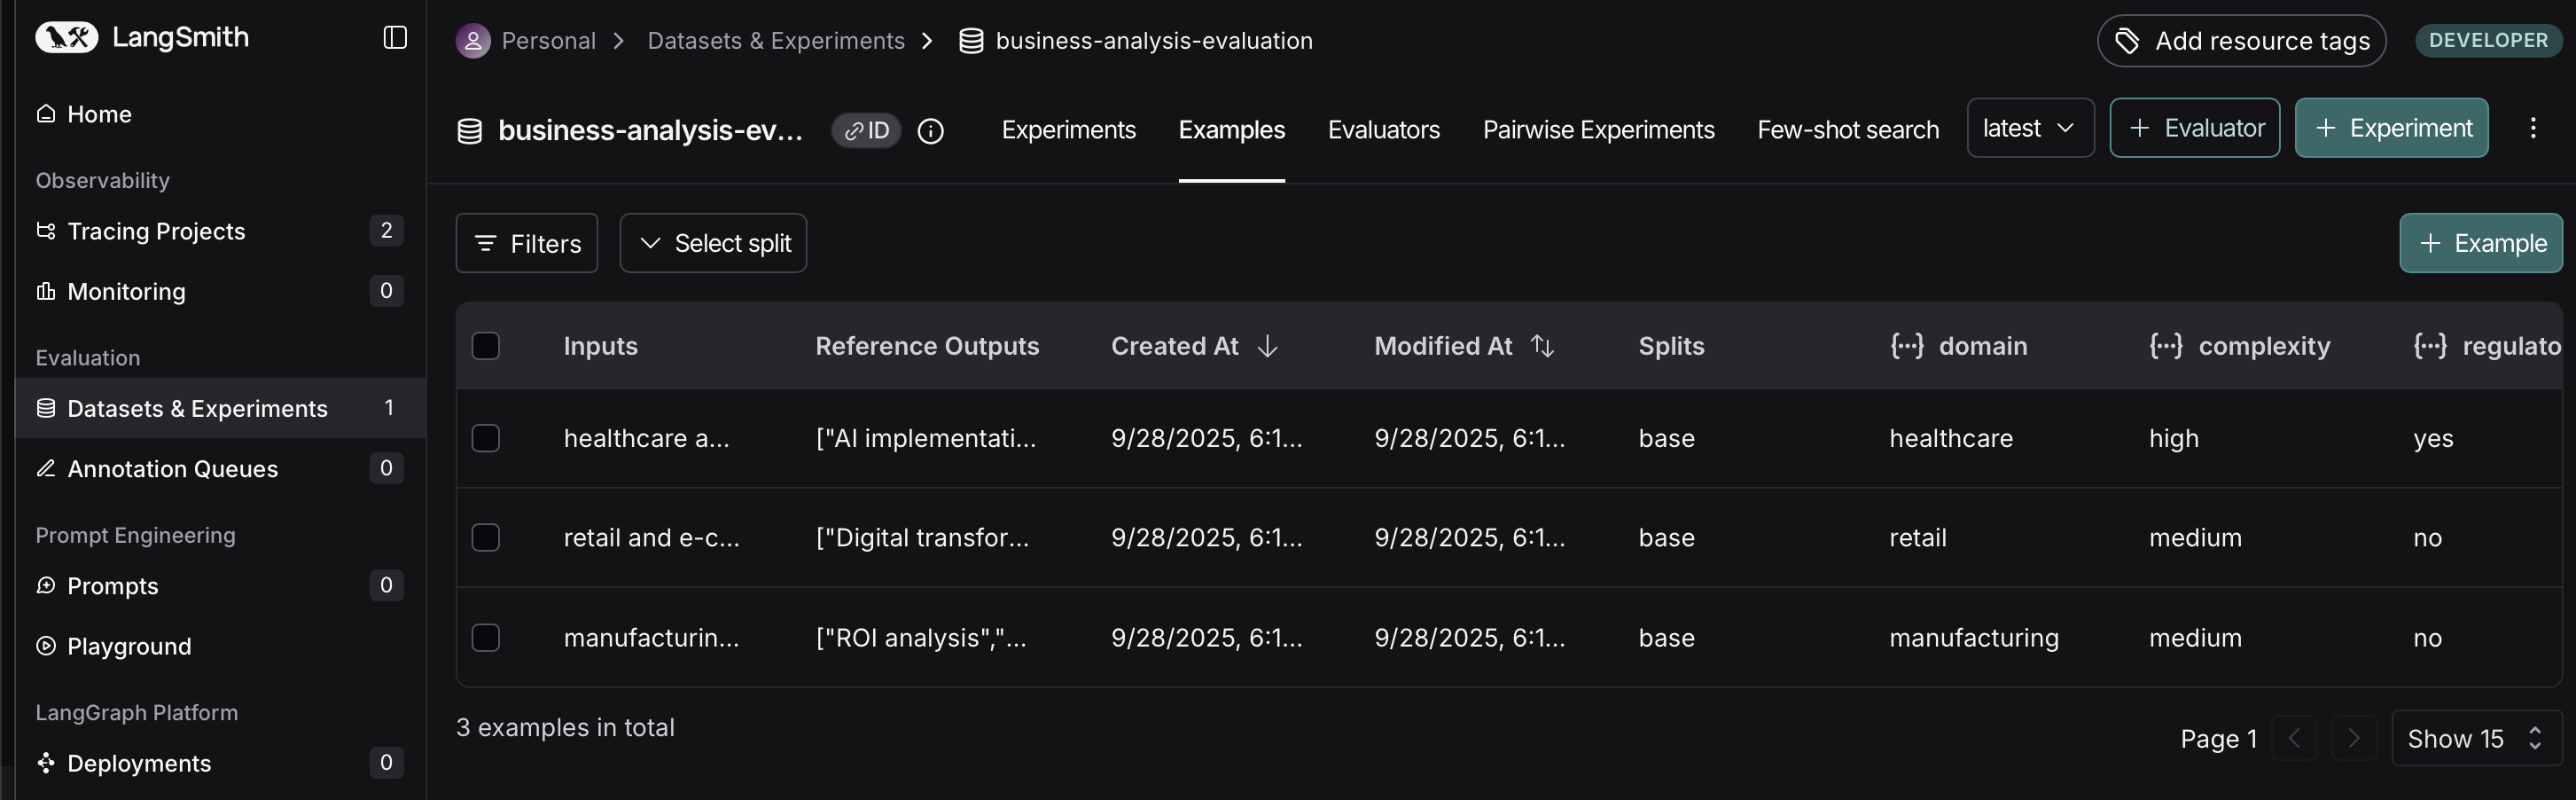

In [8]:
# Printing example of dataset
import os
from IPython.display import Image, display

notebook_dir = os.path.dirname(os.path.abspath(''))
image_path = os.path.join(notebook_dir, 'week_04', 'images', 'example_04.png')

if os.path.exists(image_path):
    display(Image(image_path))
else:
    print(f"Image not found at: {image_path}")

---
## 5. Code Evaluator

Evaluators are functions that measure how well your application performs on a specific example.

They take two main inputs:

- `Example`: the dataset item, including inputs, reference outputs, and metadata.
- `Run`: the actual outputs and intermediate steps generated when processing the example.

As output, an evaluator returns metrics in a dictionary (or list). Each metric includes:
- `key`: the metric name.
- `score` (numeric) or `value` (categorical).
- `comment` (optional), to explain or justify the result.

Evaluators can be defined in two ways:

- `Custom evaluators` in Python or TypeScript, run via SDKs or the UI.
- `Built-in evaluators` provided by LangSmith, configurable in the UI.

In [9]:
from langsmith.evaluation import evaluate
from langsmith.evaluation.evaluator import EvaluationResult

# Defining custom evaluators for business analysis

# Defining a structure evaluator that checks if the response has a certain structure
def structure_evaluator(run: Run, example: Example) -> EvaluationResult:
    """Evaluate if the response has proper structure. This is a custom evaluator."""
    response = run.outputs.get('output', '')
    
    # Check for required sections
    # Creating an evaluator that checks if the response has a certain structure
    required_sections = ['Key Insights', 'Risk Assessment', 'Strategic Recommendations']
    found_sections = sum(1 for section in required_sections if section in response)
    
    # Calculating the score based on the number of required sections found
    score = found_sections / len(required_sections)
    
    return EvaluationResult( # Returning the evaluation result
        key="structure_score",
        score=score,
        comment=f"Found {found_sections}/{len(required_sections)} required sections"
    )

# Defining a length evaluator that checks if the response is of an appropriate length
def length_evaluator(run: Run, example: Example) -> EvaluationResult:
    """Evaluate response length appropriateness. This is a custom evaluator."""
    response = run.outputs.get('output', '')
    word_count = len(response.split())
    
    # Score based on appropriate length (200-800 words)
    if word_count < 200:
        score = 0.3
        comment = "Response too short"
    elif word_count > 800:
        score = 0.7
        comment = "Response too long"
    else:
        score = 1.0
        comment = "Appropriate length"
    
    return EvaluationResult(
        key="length_score",
        score=score,
        comment=f"{word_count} words - {comment}"
    )

# Defining a domain relevance evaluator that checks if the response is relevant to the industry
def domain_relevance_evaluator(run: Run, example: Example) -> EvaluationResult:
    """Evaluate domain-specific relevance. This is a custom evaluator."""
    response = run.outputs.get('output', '').lower()
    industry = example.inputs.get('industry', '').lower()
    
    # Check for industry-specific keywords
    # Note: This is a simple example and may not cover all industry-specific keywords
    industry_keywords = {
        'healthcare': ['patient', 'medical', 'health', 'clinical', 'diagnosis'],
        'manufacturing': ['production', 'automation', 'efficiency', 'operations'],
        'retail': ['customer', 'sales', 'e-commerce', 'digital', 'online']
    }
    
    # Getting the keywords for the industry
    keywords = industry_keywords.get(industry.split()[0], [])
    
    # Counting the number of keywords found in the response
    found_keywords = sum(1 for keyword in keywords if keyword in response)
    
    # Calculating the score based on the number of keywords found
    score = min(found_keywords / max(len(keywords), 1), 1.0)
    
    return EvaluationResult(
        key="domain_relevance",
        score=score,
        comment=f"Found {found_keywords}/{len(keywords)} domain keywords"
    )

print("Custom evaluators defined successfully!")

Custom evaluators defined successfully!


In [10]:
# https://docs.smith.langchain.com/reference/python/evaluation/langsmith.evaluation._runner.evaluate?_gl=1*1d6tkoz*_gcl_au*MzMxNjM0NTA3LjE3NTg0NDYzMTA.*_ga*MjA5NjUzNDI3LjE3NTU1MTg5NzI.*_ga_47WX3HKKY2*czE3NTkxMTQ2NDUkbzIwNSRnMSR0MTc1OTExNjI0NSRqNjAkbDAkaDA.#evaluate
# Now let's run our evaluation on the dataset.
try:
    evaluation_result = evaluate(
        business_analysis_app, #The example.inputs field of each Example is what gets passed to the target function. In this case our business_analysis_app is already set up to take in example inputs so we can use it directly.
        data=dataset_name, #The data field is the dataset name or ID.
        evaluators=[ #The evaluators field is a list of evaluators to use.
            structure_evaluator,
            length_evaluator,
            domain_relevance_evaluator
        ],
        experiment_prefix="business-analysis-eval", # Optional: A prefix for the experiment name.
        max_concurrency=2 # Optional: The maximum number of concurrent runs.
    )
    print("Evaluation completed successfully!")
    
except Exception as e:
    print(f"Error running evaluation: {e}")


View the evaluation results for experiment: 'business-analysis-eval-3aa49de6' at:
https://smith.langchain.com/o/83c9c0ff-12ce-4213-a780-fd036553c0bb/datasets/d6d0971a-4f83-4339-a08d-21e67bd5ac09/compare?selectedSessions=23356e5e-8c9a-4b64-be2f-cc629caae8a6




0it [00:00, ?it/s]

Evaluation completed successfully!


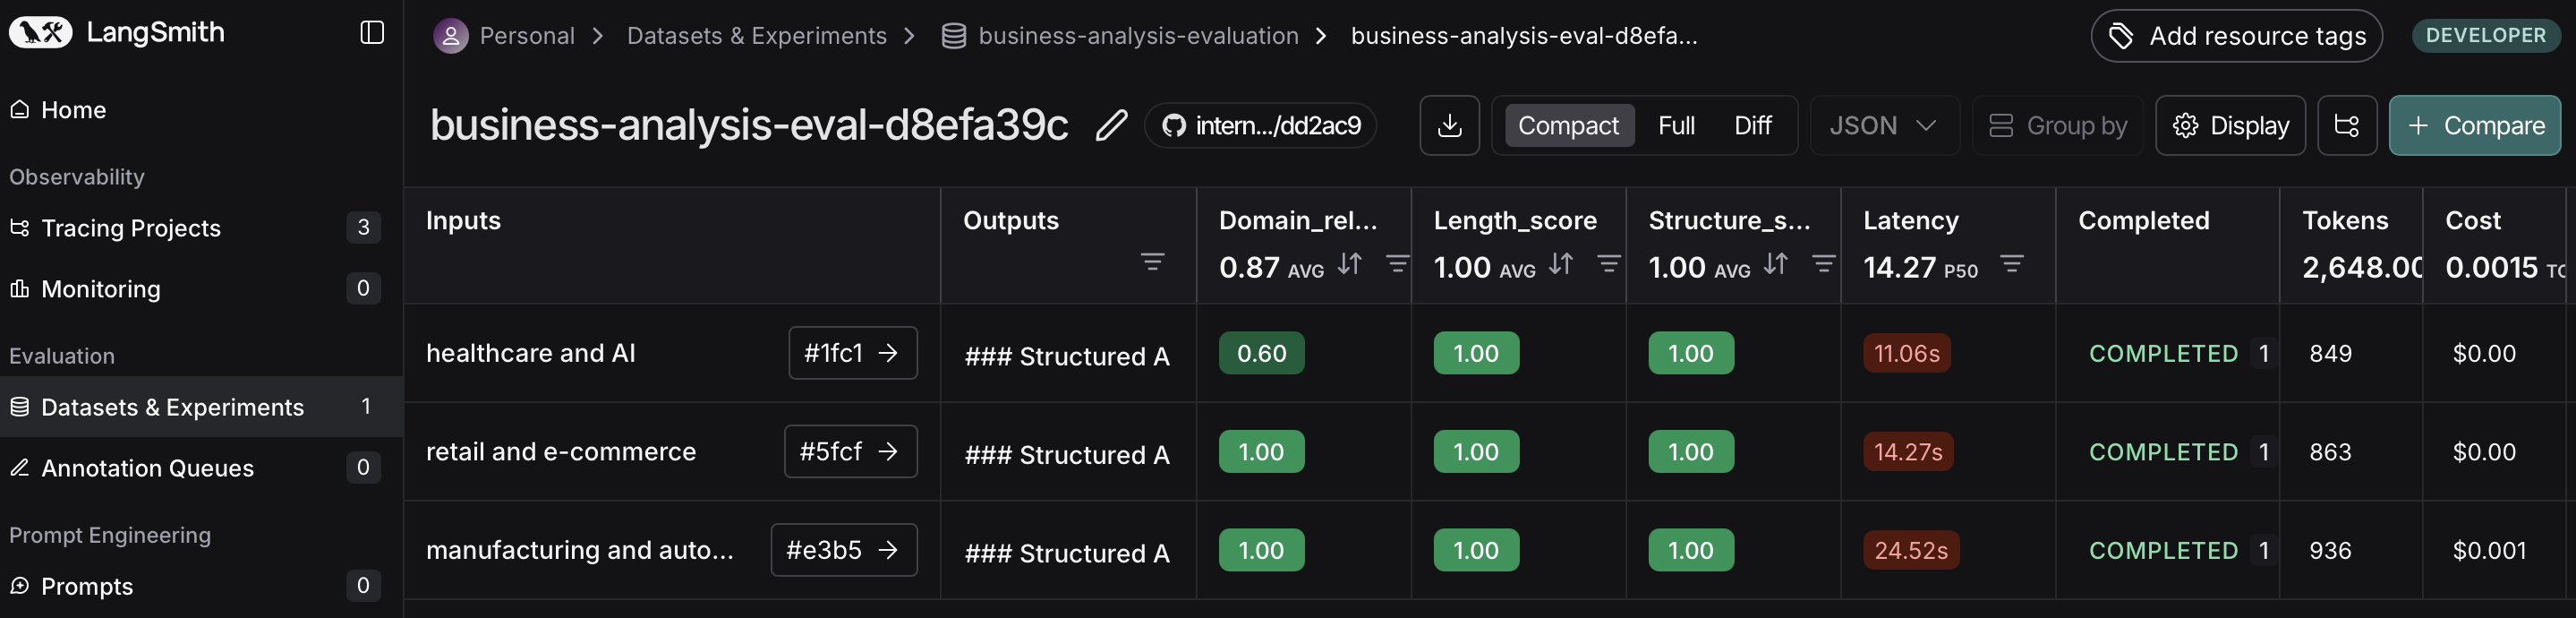

In [11]:
# Printing evaluation
image_path = os.path.join(notebook_dir, 'week_04', 'images', 'example_05.png')

if os.path.exists(image_path):
    display(Image(image_path))
else:
    print(f"Image not found at: {image_path}")

---
## 6. LLM-as-Judge Evaluation

Evaluating LLM applications can be difficult, since they often produce open-ended conversational text without a single “correct” answer. An LLM-as-a-judge evaluator addresses this by using another model to score or compare outputs.

*Let's implement an LLM-as-judge evaluator for more sophisticated assessment.*

In [12]:
# Create LLM-as-judge evaluator
def business_quality_judge(run: Run, example: Example) -> EvaluationResult:
    """LLM-as-judge evaluator for business analysis quality."""
    
    response = run.outputs.get('output', '')
    scenario = example.inputs.get('scenario', '')
    industry = example.inputs.get('industry', '')
    
    judge_prompt = f"""
    You are an expert business analyst evaluating the quality of a business analysis.
    
    Scenario: {scenario}
    Industry: {industry}
    
    Analysis to evaluate:
    {response}
    
    Rate the analysis on a scale of 0-1 for each criterion:
    1. Strategic Depth (0-1): Does it provide strategic insights?
    2. Risk Awareness (0-1): Does it identify key risks?
    3. Actionability (0-1): Are recommendations specific and actionable?
    4. Industry Relevance (0-1): Is it relevant to the industry context?
    
    Provide your scores and brief reasoning for each criterion.
    """
    
    try:
        judge_response = client.invoke([HumanMessage(content=judge_prompt)])
        judge_content = judge_response.content
        
        # Extract scores (simplified parsing)
        lines = judge_content.split('\n')
        scores = []
        for line in lines:
            if ':' in line and any(char.isdigit() for char in line):
                try:
                    score = float(line.split(':')[-1].strip().split()[0])
                    if 0 <= score <= 1:
                        scores.append(score)
                except:
                    continue
        
        avg_score = sum(scores) / len(scores) if scores else 0.5
        
        return EvaluationResult(
            key="business_quality",
            score=avg_score,
            comment=f"LLM Judge Score: {avg_score:.2f} - {judge_content[:300]}..."
        )
        
    except Exception as e:
        return EvaluationResult(
            key="business_quality",
            score=0.5,
            comment=f"Error in LLM evaluation: {str(e)}"
        )

print("LLM-as-judge evaluator created successfully!")

LLM-as-judge evaluator created successfully!


In [13]:
# Run evaluation with LLM-as-judge
try:
    evaluation_result = evaluate(
        business_analysis_app,
        data=dataset_name,
        evaluators=[business_quality_judge],
        experiment_prefix="business-analysis-eval-llm-judge",
        max_concurrency=1
    )
    print("LLM-as-judge evaluation completed successfully!")
    
except Exception as e:
    print(f"Error running LLM-as-judge evaluation: {e}")


View the evaluation results for experiment: 'business-analysis-eval-llm-judge-d5a9bd65' at:
https://smith.langchain.com/o/83c9c0ff-12ce-4213-a780-fd036553c0bb/datasets/d6d0971a-4f83-4339-a08d-21e67bd5ac09/compare?selectedSessions=8c2fa43e-d019-4e82-a54f-ee8ca1f1411a




0it [00:00, ?it/s]

LLM-as-judge evaluation completed successfully!


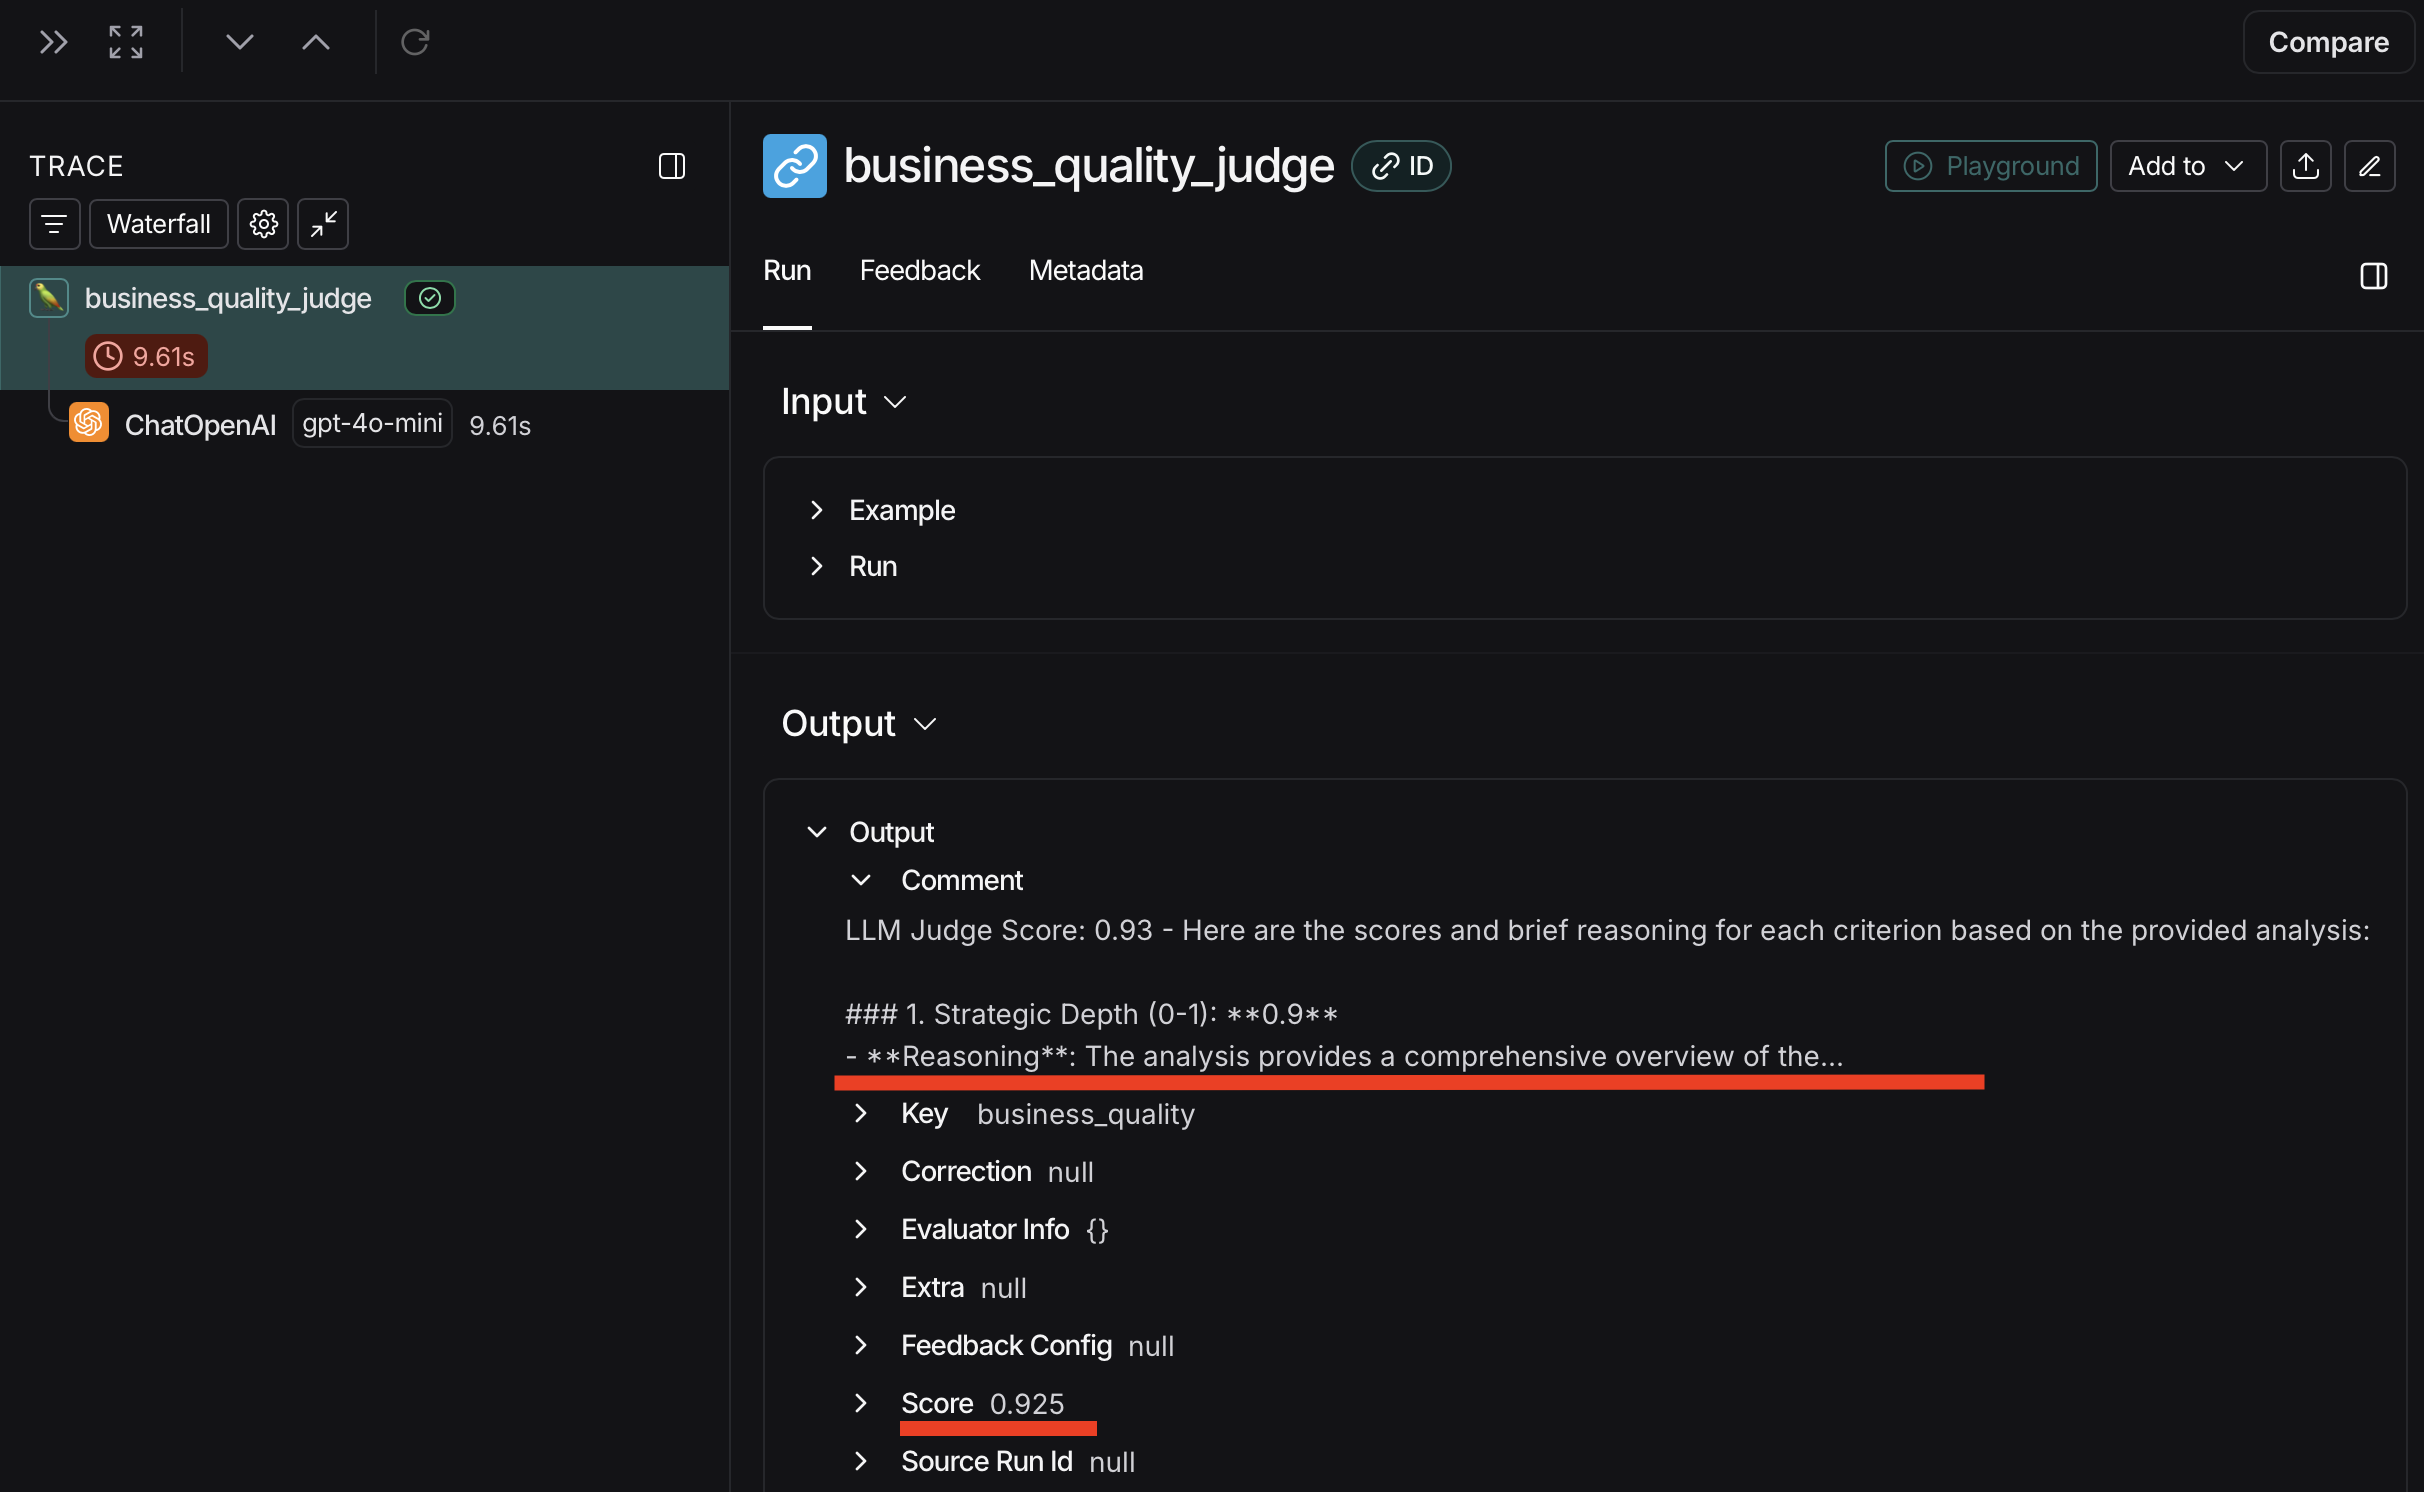

In [14]:
# Printing LLM-as-judge evaluation
image_path = os.path.join(notebook_dir, 'week_04', 'images', 'example_06.png')

if os.path.exists(image_path):
    display(Image(image_path))
else:
    print(f"Image not found at: {image_path}")

---
## 7. Summary Evaluator

Summary evaluators compute metrics at the experiment level by aggregating results from all individual runs together. The objective is to perform evaluation across the entire dataset rather than on single responses.

In our case, we define custom summary evaluators designed for business analysis outputs:

- **Keyword Coverage Evaluator***: Performs keyword matching by comparing the `expected_insights` defined in the dataset against each agent's response, checking for keyword presence to generate a proportional coverage score (0.0 to 1.0) across all runs.

- **Average Quality Score Evaluator**: Computes the average quality score across all responses, factoring in word length, structural completeness, and industry relevance based on domain-specific keywords.

These evaluators allow us to measure both the consistency and the overall quality of model outputs by aggregating results from all individual runs in the experiment.


In [15]:
# Summary evaluators work at the experiment level, not individual runs

# This is a custom summary evaluator that calculates the keyword coverage across all examples in the EXPERIMENT
# It's a simple custom evaluator that checks if the response contains the expected insights that we previously defined in the dataset

# Important: This is a simple example and may not be the most meaningful metric for evaluating system correctness, as keyword presence alone may not accurately reflect the quality or relevance of agent-generated responses in real-world applications.
def keyword_coverage_summary_evaluator(outputs: list[dict], reference_outputs: list[dict]) -> dict:
    """
    Calculate keyword coverage across all examples in the experiment.

    This evaluator performs simple keyword matching by checking if specific 
    keywords from expected_insights are present in the agent's response. 
    It returns a proportional score (0.0 to 1.0) based on keyword presence.
    """
   
    total_examples = len(outputs)
    total_score = 0.0
    
    for output_dict, reference_output_dict in zip(outputs, reference_outputs):
        # Get the output and expected insights from the reference outputs
        output = output_dict.get("output", "")
        expected_insights = reference_output_dict.get("expected_insights", [])
        
        # Check if the response contains the expected insights
        # Note: Our keyword coverage summary evaluator performs KEYWORD MATCHING by comparing the expected_insights defined in the dataset against the agent's response, checking for keyword presence to generate a basic evaluation score.
        # Reminder: The expected_insights is a list of strings that we created as expected output for the dataset
        found_insights = 0
        for insight in expected_insights:
            if insight.lower() in output.lower():
                found_insights += 1
        
        # Calculate proportional score (0.0 to 1.0) based on coverage
        if len(expected_insights) > 0:
            coverage_score = found_insights / len(expected_insights)  # 0.0 to 1.0
        else:
            coverage_score = 0.0
        
        total_score += coverage_score
    
    # Calculate average coverage across all examples
    avg_coverage = total_score / total_examples if total_examples > 0 else 0.0
    
    return {
        "key": "keyword_coverage", 
        "score": avg_coverage,  # Returns proportional score (0.0 to 1.0)
        "comment": f"Average coverage: {avg_coverage:.2f} ({avg_coverage*100:.1f}% of expected insights found across all examples)"
    }

# Average quality score summary evaluator
def average_quality_summary_evaluator(outputs: list[dict], reference_outputs: list[dict]) -> dict:
    """
    Calculate average quality score across all examples based on three quality dimensions:
    
    1. LENGTH: Ensures responses are appropriately sized (200-800 words)
    2. STRUCTURE: Verifies responses follow business analysis format (insights, risks, recommendations)
    3. DOMAIN RELEVANCE: Checks if responses use industry-appropriate terminology
    
    This provides a technical quality assessment independent of content accuracy.
    """

    quality_scores = []
    
    for output_dict, reference_output_dict in zip(outputs, reference_outputs):
        output = output_dict.get("output", "")
        
        # 1. LENGTH SCORE: Check if response has appropriate word count
        word_count = len(output.split())
        length_score = 1.0 if 200 <= word_count <= 800 else 0.5
        
        # 2. STRUCTURE SCORE: Verify response follows business analysis format
        has_structure = any(section in output.lower() for section in ["insight", "risk", "recommendation"])
        structure_score = 1.0 if has_structure else 0.0
        
        # 3. DOMAIN RELEVANCE SCORE: Check industry-specific terminology usage
        industry = reference_output_dict.get("metadata", {}).get("domain", "")
        industry_keywords = {
            "healthcare": ["patient", "medical", "health", "clinical"],
            "manufacturing": ["production", "automation", "efficiency"],
            "retail": ["customer", "sales", "e-commerce", "digital"]
        }
        # Count how many industry-relevant keywords appear in the response
        keywords = industry_keywords.get(industry, [])
        relevance_score = sum(1 for keyword in keywords if keyword in output.lower()) / max(len(keywords), 1)
        
        # Calculate overall quality score as average of all three dimensions
        overall_score = (length_score + structure_score + relevance_score) / 3
        quality_scores.append(overall_score)
    
    avg_quality = sum(quality_scores) / len(quality_scores) if quality_scores else 0.0
    
    return {
        "key": "average_quality",
        "score": avg_quality,
        "comment": f"Average quality score: {avg_quality:.2f} across {len(quality_scores)} examples"
    }

print("Summary evaluators created successfully!")


Summary evaluators created successfully!


In [16]:
# Run evaluation with summary evaluators
try:
    # Run evaluation with both regular and summary evaluators
    evaluation_result = evaluate(
        business_analysis_app,
        data=dataset_name,
        evaluators=[structure_evaluator, length_evaluator],  # Regular evaluators (per run)
        summary_evaluators=[keyword_coverage_summary_evaluator, average_quality_summary_evaluator],  # Summary evaluators (experiment level)
        experiment_prefix="business-analysis-with-summary",
        max_concurrency=1
    )    
    print("Evaluation with summary evaluators completed!")
    
except Exception as e:
    print(f"Error running evaluation with summary evaluators: {e}")

View the evaluation results for experiment: 'business-analysis-with-summary-3830b593' at:
https://smith.langchain.com/o/83c9c0ff-12ce-4213-a780-fd036553c0bb/datasets/d6d0971a-4f83-4339-a08d-21e67bd5ac09/compare?selectedSessions=bbad5f0d-fb7d-4d6a-bfe5-0d417633bbbf




0it [00:00, ?it/s]

Evaluation with summary evaluators completed!


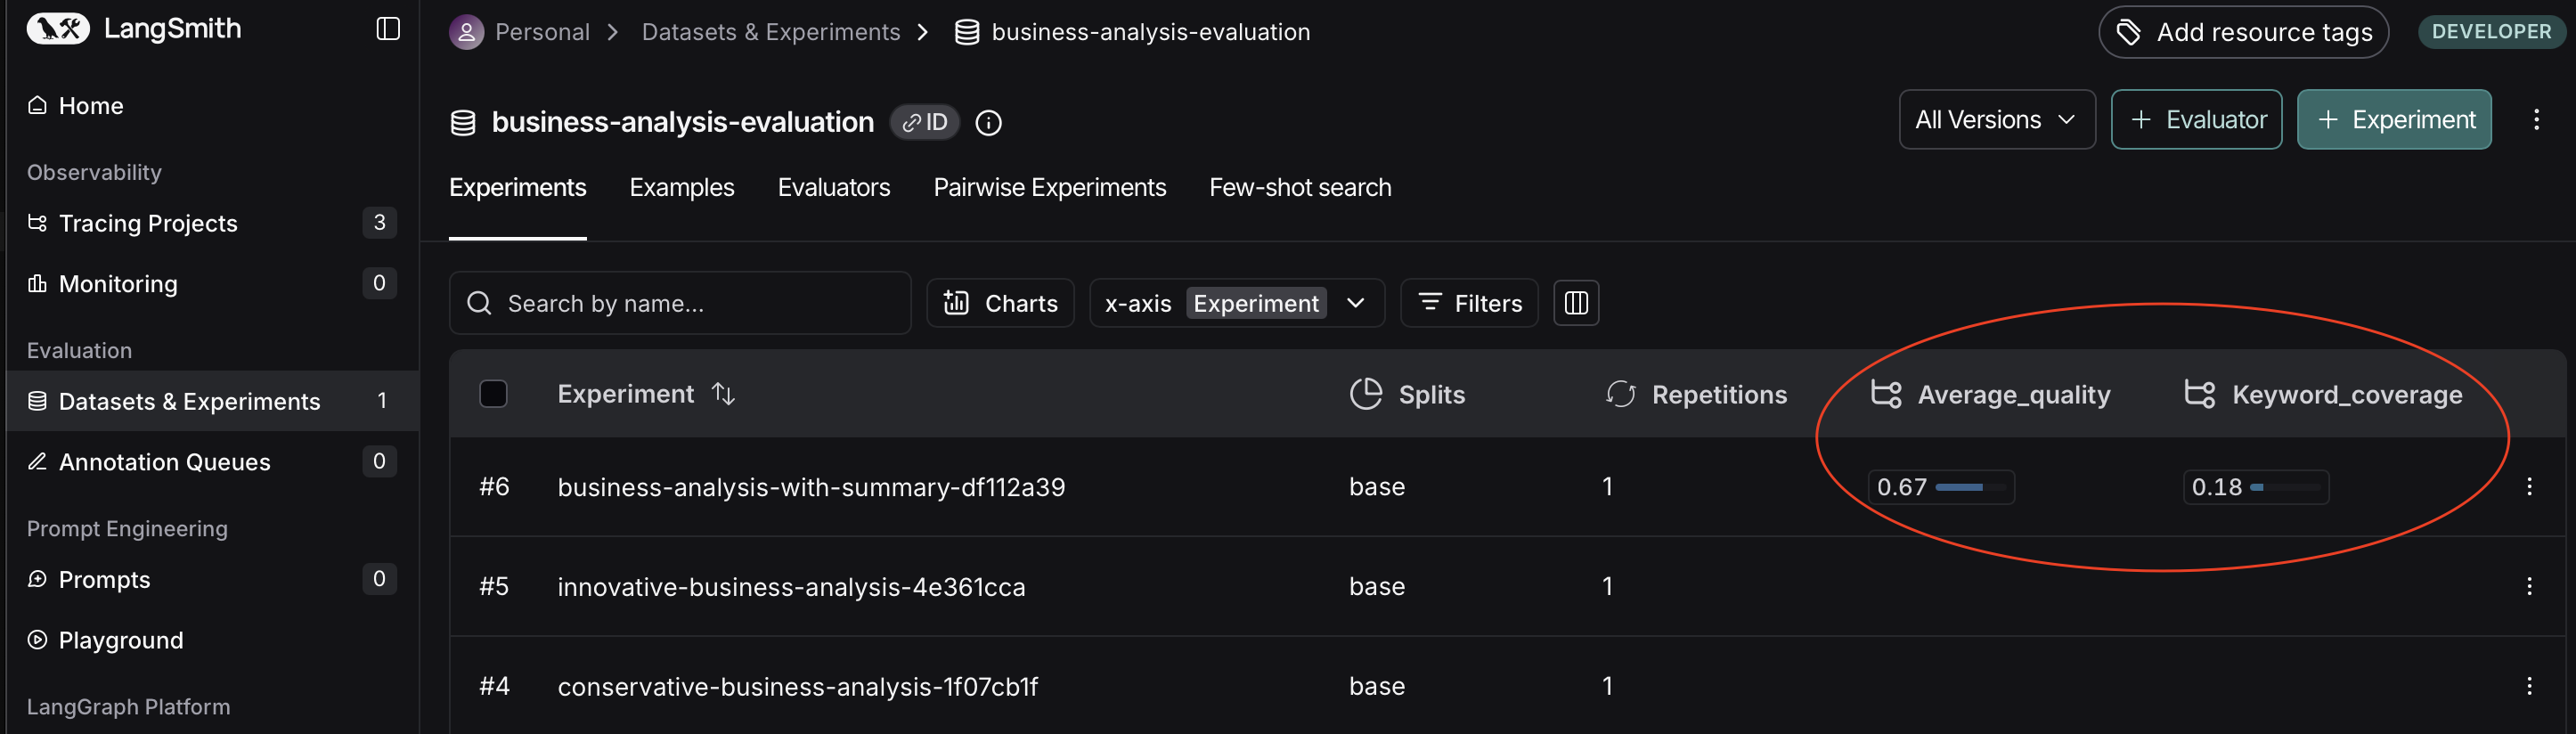

In [17]:
# Printing evaluation
image_path = os.path.join(notebook_dir, 'week_04', 'images', 'example_07.png')

if os.path.exists(image_path):
    display(Image(image_path))
else:
    print(f"Image not found at: {image_path}")

---

## 8. Pairwise Evaluation

LangSmith also supports comparative evaluations, where outputs from multiple experiments are scored against each other rather than individually. Using the `evaluate()` function, you can run pairwise evaluations by comparing results from two existing experiments with a custom evaluator. The LangSmith UI then provides a clear view of these pairwise comparisons.

In [18]:
# Step 1: Create two different business analysis approaches
# We'll run separate experiments first, then compare them

@traceable
def business_analysis_conservative(inputs: dict) -> dict:
    """Conservative business analysis approach."""
    scenario = inputs.get('scenario', '')
    industry = inputs.get('industry', '')
    
    system_prompt = f"""You are a conservative business analyst specializing in {industry}.
    Provide a risk-focused analysis with:
    1. Key Insights
    2. Risk Assessment
    3. Strategic Recommendations
    4. Implementation Timeline
    
    Focus on risk mitigation and conservative strategies."""
    
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Analyze this scenario: {scenario}")
    ]
    
    response = client.invoke(messages)
    return {"output": response.content}

@traceable
def business_analysis_innovative(inputs: dict) -> dict:
    """Innovative business analysis approach."""
    scenario = inputs.get('scenario', '')
    industry = inputs.get('industry', '')
    
    system_prompt = f"""You are an innovative business strategist specializing in {industry}.
    Provide a creative and forward-thinking analysis with:
    1. Executive Summary
    2. Market Opportunities
    3. Competitive Landscape
    4. Risk Assessment
    5. Strategic Recommendations
    6. Implementation Roadmap
    7. Success Metrics
    
    Focus on innovation and growth opportunities."""
    
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Analyze this scenario: {scenario}")
    ]
    
    response = client.invoke(messages)
    return {"output": response.content}

print("Two different analysis approaches created!")


Two different analysis approaches created!


In [19]:
# Step 2: Run separate experiments first
print("Running first experiment (Conservative approach)...")

try:
    conservative_experiment = evaluate(
        business_analysis_conservative,
        data=dataset_name,
        evaluators=[structure_evaluator, length_evaluator], # This is the same evaluators used in the previous experiment, this does not matter for pairwise evaluation
        experiment_prefix="conservative-business-analysis",
        max_concurrency=1
    )
    print("Conservative experiment completed!")
    
except Exception as e:
    print(f"Error running conservative experiment: {e}")
    conservative_experiment_name = "conservative-business-analysis-fallback"


Running first experiment (Conservative approach)...
View the evaluation results for experiment: 'conservative-business-analysis-72cf21f4' at:
https://smith.langchain.com/o/83c9c0ff-12ce-4213-a780-fd036553c0bb/datasets/d6d0971a-4f83-4339-a08d-21e67bd5ac09/compare?selectedSessions=8943b8cf-ba84-4f06-8692-8b00dc999d99




0it [00:00, ?it/s]

Conservative experiment completed!


In [20]:
print("Running second experiment (Innovative approach)...")

try:
    innovative_experiment = evaluate(
        business_analysis_innovative,
        data=dataset_name,
        evaluators=[structure_evaluator, length_evaluator], # This is the same evaluators used in the previous experiment, this does not matter for pairwise evaluation
        experiment_prefix="innovative-business-analysis",
        max_concurrency=1
    )
    print("Innovative experiment completed!")
    
except Exception as e:
    print(f"Error running innovative experiment: {e}")
    innovative_experiment_name = "innovative-business-analysis-fallback"


Running second experiment (Innovative approach)...
View the evaluation results for experiment: 'innovative-business-analysis-44040fb8' at:
https://smith.langchain.com/o/83c9c0ff-12ce-4213-a780-fd036553c0bb/datasets/d6d0971a-4f83-4339-a08d-21e67bd5ac09/compare?selectedSessions=bc4e0fa7-7178-4e6e-86da-d856399ed53a




0it [00:00, ?it/s]

Innovative experiment completed!


In [21]:
# Step 3: Create pairwise evaluator following LangSmith documentation
def business_analysis_pairwise_evaluator(inputs: dict, outputs: list[dict]) -> list:
    """
    Pairwise evaluator that compares two business analysis approaches.
    Returns scores for each approach: [score_a, score_b].
    One must win, no ties allowed.
    """
    
    scenario = inputs.get('scenario', '')
    industry = inputs.get('industry', '')
    
    # Get outputs from both experiments
    conservative_output = outputs[0].get('output', '')
    innovative_output = outputs[1].get('output', '')
    
    # Create comparison prompt
    comparison_prompt = f"""
    You are an expert business analyst comparing two business analysis approaches.

    Scenario: {scenario}
    Industry: {industry}

    Conservative Analysis:
    {conservative_output}

    Innovative Analysis:
    {innovative_output}

    Which analysis is better for business decision-making?
    Consider: strategic depth, risk awareness, actionability, and clarity.

    Respond with:
    - Winner: Conservative or Innovative
    - Score: 1 for Conservative, 2 for Innovative
    - Reasoning: Brief explanation
    """

    try:
        comparison_response = client.invoke([HumanMessage(content=comparison_prompt)])
        comparison_content = comparison_response.content.lower()
        
        # Parse the response to determine scores
        if 'winner: innovative' in comparison_content or 'score: 2' in comparison_content:
            scores = [0, 1]  # Innovative wins
        else:
            # Default to Conservative if not clearly Innovative
            scores = [1, 0]  # Conservative wins
        
        return scores
        
    except Exception as e:
        print(f"Error in pairwise evaluation: {e}")
        # If there's an error, do not return any score
        return [0, 0]

print("Pairwise evaluator created successfully!")


Pairwise evaluator created successfully!


In [22]:
# Step 4: Run pairwise evaluation comparing the two experiments
print("Running pairwise evaluation...")

# NOTE: You need to use the actual experiment names/IDs

id_conservative = "conservative-business-analysis-72cf21f4" # <---- Set this to the actual experiment name/ID
id_innovative = "innovative-business-analysis-44040fb8" # <---- Set this to the actual experiment name/ID

try:
    pairwise_result = evaluate(
        (id_innovative, id_conservative),
        evaluators=[business_analysis_pairwise_evaluator],
        randomize_order=True,  # Minimize positional bias
        max_concurrency=2,
        experiment_prefix="pairwise-business-analysis-comparison"
    )
    
    print("Pairwise evaluation completed successfully!")
    print("View results in LangSmith UI under 'Pairwise Experiments' tab")
    
except Exception as e:
    print(f"Error running pairwise evaluation: {e}")
    print("\nNote: Pairwise evaluation requires two existing experiments to compare.")
    print("Make sure both experiments completed successfully before running pairwise evaluation.")


Running pairwise evaluation...
View the pairwise evaluation results at:
https://smith.langchain.com/o/83c9c0ff-12ce-4213-a780-fd036553c0bb/datasets/d6d0971a-4f83-4339-a08d-21e67bd5ac09/compare?selectedSessions=bc4e0fa7-7178-4e6e-86da-d856399ed53a%2C8943b8cf-ba84-4f06-8692-8b00dc999d99&comparativeExperiment=d19ffc72-97cd-47a3-a017-5c05a9ab42a3




  0%|          | 0/3 [00:00<?, ?it/s]

Pairwise evaluation completed successfully!
View results in LangSmith UI under 'Pairwise Experiments' tab


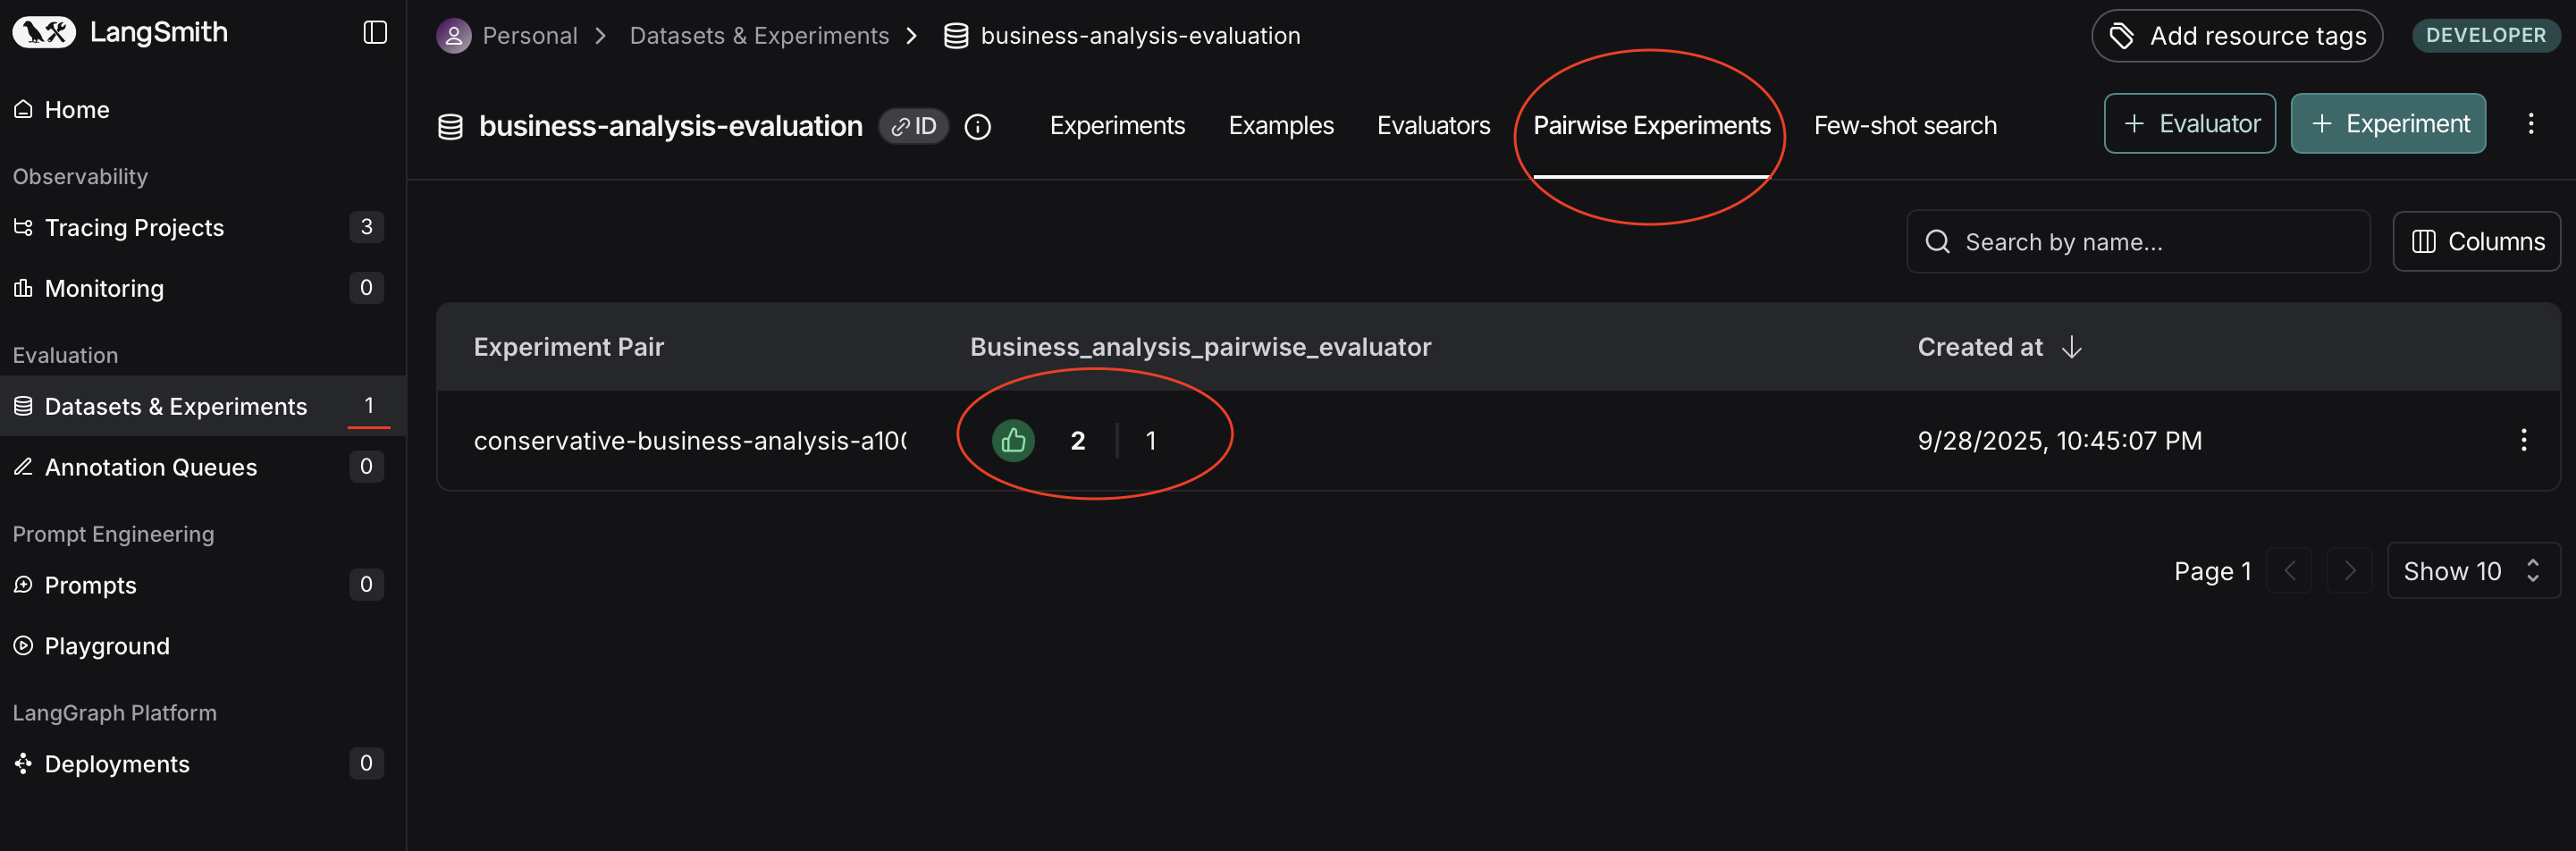

In [23]:
# Printing Pairwise Evaluation
image_path = os.path.join(notebook_dir, 'week_04', 'images', 'example_08.png')

if os.path.exists(image_path):
    display(Image(image_path))
else:
    print(f"Image not found at: {image_path}")

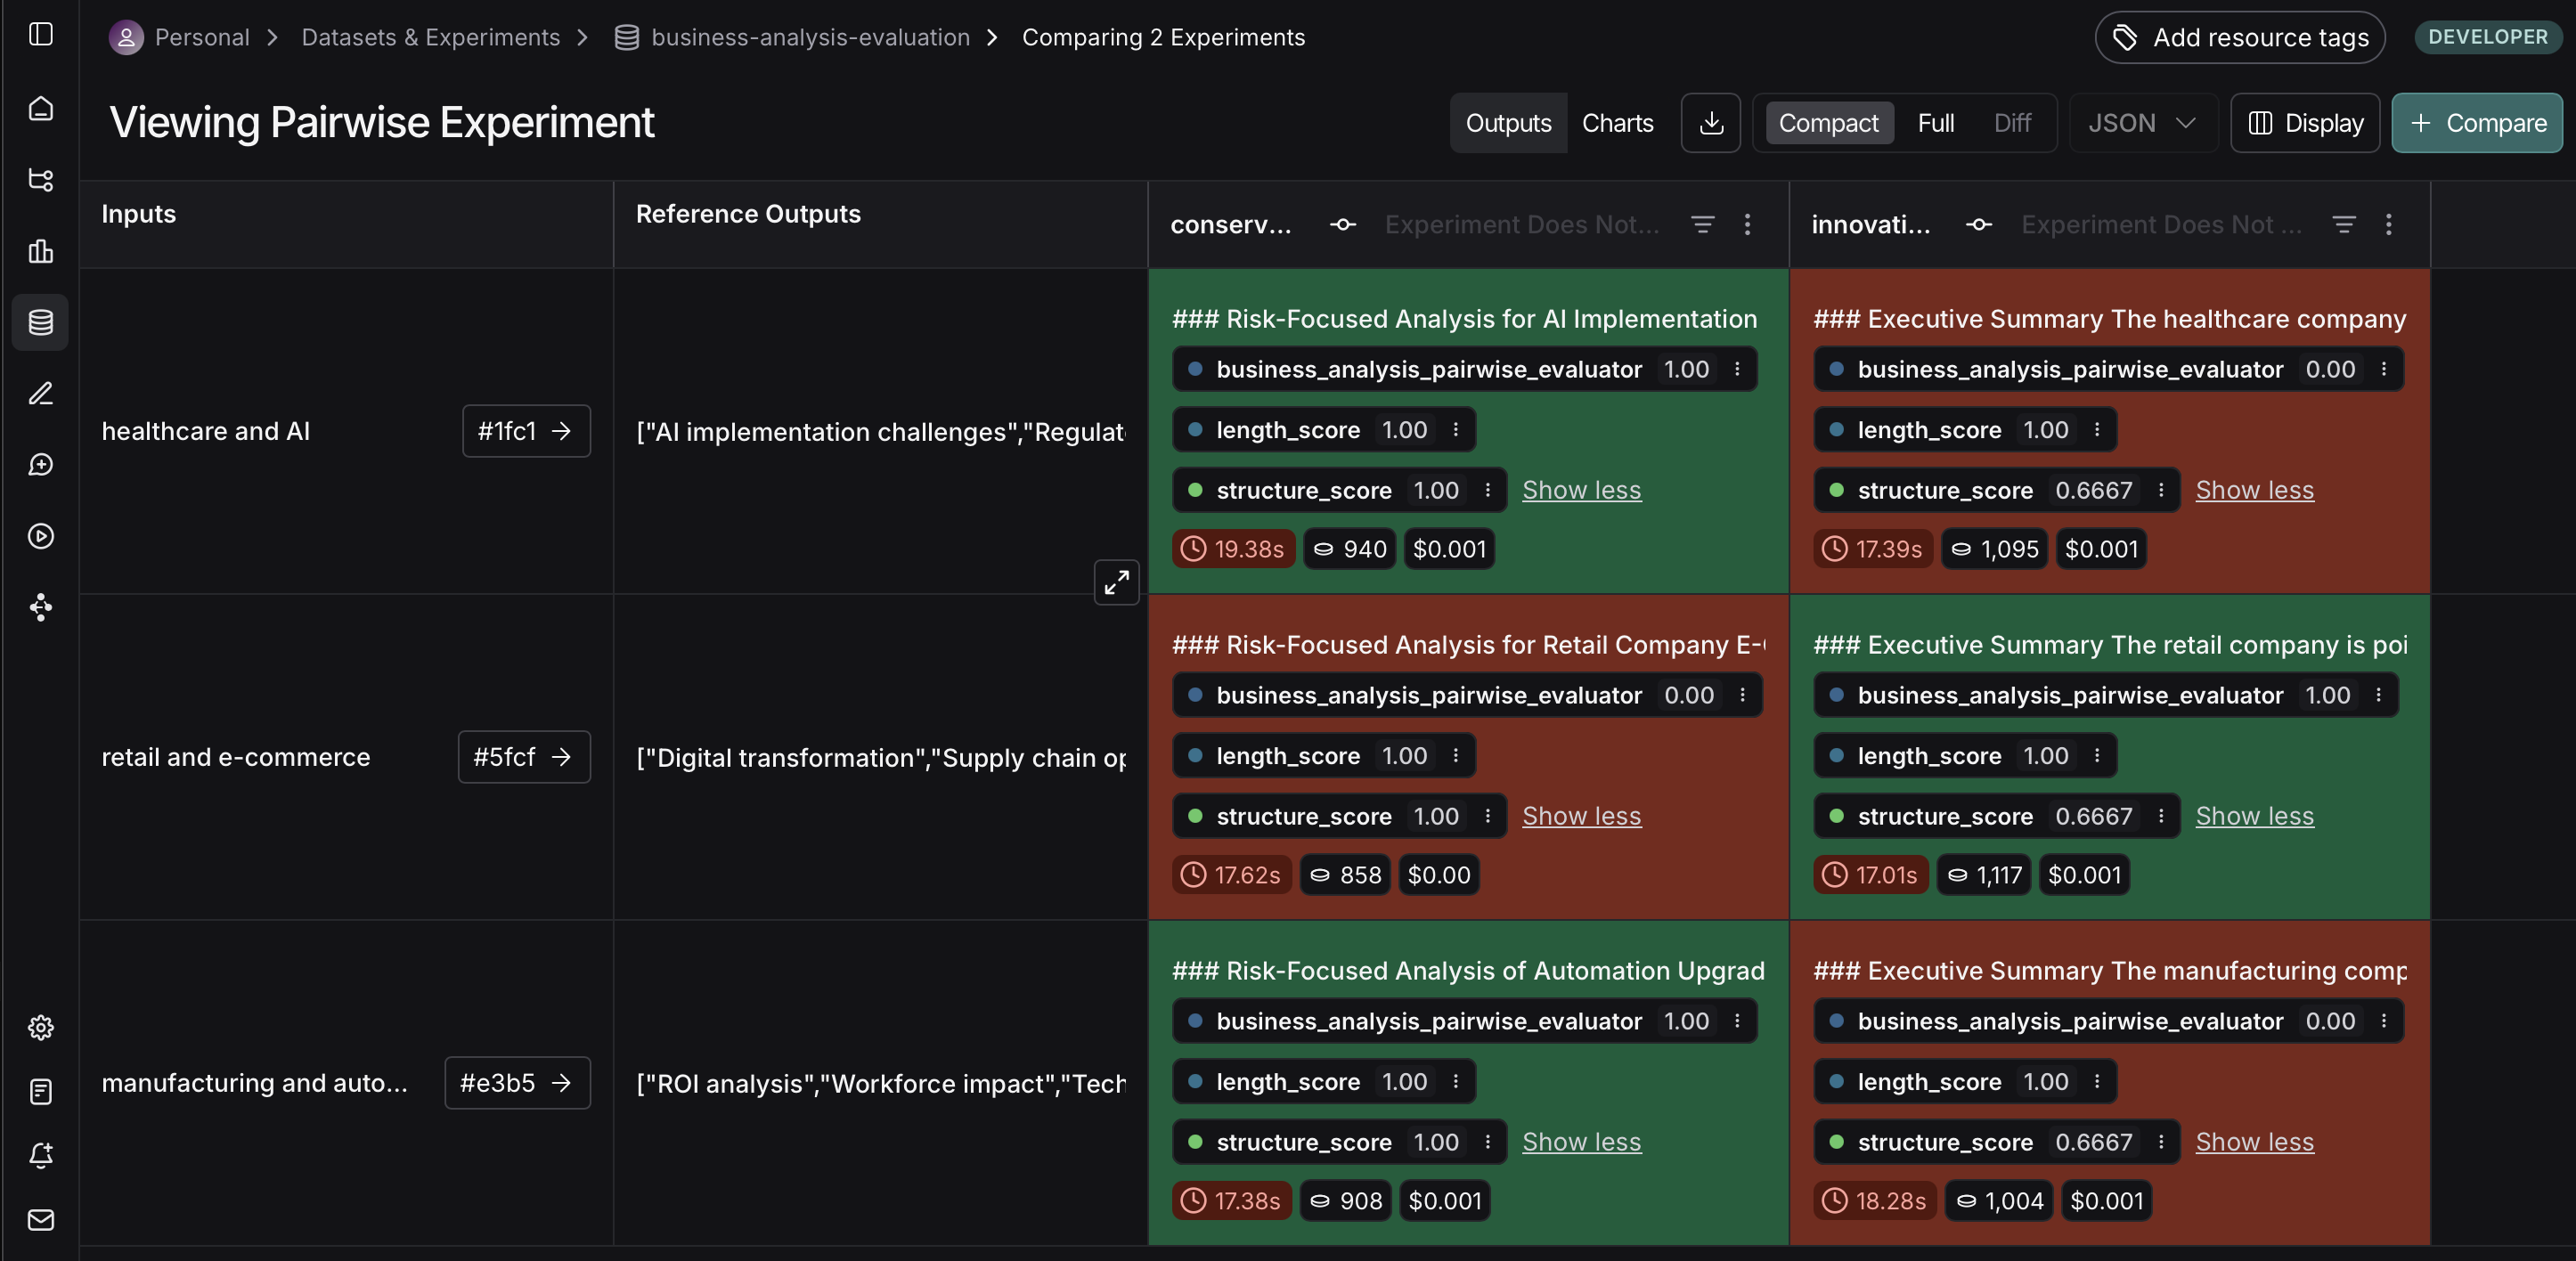

In [24]:
# Printing Pairwise Comparison
image_path = os.path.join(notebook_dir, 'week_04', 'images', 'example_09.png')

if os.path.exists(image_path):
    display(Image(image_path))
else:
    print(f"Image not found at: {image_path}")

#### Key Differences: Regular vs Pairwise Evaluation

#### Regular Evaluation
- Evaluates **one application** against a dataset
- Uses `evaluate(app_function, data=dataset, evaluators=[...])`
- Returns individual scores for each example

#### Pairwise Evaluation
- Compares **two existing experiments** against each other
- Uses `evaluate((experiment1, experiment2), evaluators=[...])`
- Returns comparative scores: `[score_a, score_b]`


---

## 12. Key Takeaways

### Best Practices

- **Start Simple**: Begin with basic evaluators and gradually add complexity
- **Domain-Specific**: Create evaluators tailored to your business domain
- **Human Feedback**: Combine automated evaluation with human judgment
- **Regular Evaluation**: Establish continuous evaluation processes
- **Documentation**: Maintain clear documentation of evaluation criteria

---

**Remember**: Evaluation is an ongoing process. Continuously refine your evaluators based on real-world performance and business requirements!

---

Some of the concepts and examples in this material were adapted from the official [LangSmith documentation](https://docs.langchain.com/langsmith/evaluation-concepts). For more details, examples, and the latest updates, please refer directly to their site.
